# Fine-tuning MarianMT LR Sweep cho domain Triết học

Chạy 3 learning rate trên cùng một topic split cố định để so sánh công bằng: `1e-5`, `3e-5`, `5e-5`.


## 1. Cài đặt môi trường


In [1]:
!pip install -q transformers datasets evaluate sacrebleu sentencepiece accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.5 MB/s eta 0:00:00


## 2. Kết nối Google Drive & Import


In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import gc
import json
import random
from pathlib import Path

import evaluate
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    MarianMTModel,
    MarianTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch  : {torch.__version__}')
print(f'GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM     : {vram:.1f} GB')


PyTorch  : 2.10.0+cu128
GPU      : Tesla T4
VRAM     : 15.6 GB


## 3. Cấu hình


In [4]:
COLAB_ROOT = Path('/content/drive/MyDrive/PhilosophyMT')
if COLAB_ROOT.exists():
    DRIVE_ROOT = COLAB_ROOT
elif Path.cwd().name == 'notebooks':
    DRIVE_ROOT = Path.cwd().parent
else:
    DRIVE_ROOT = Path.cwd()

DATASET_PATH = DRIVE_ROOT / 'dataset.jsonl'
RUNS_ROOT = DRIVE_ROOT / 'runs'
SPLIT_PATH = RUNS_ROOT / 'splits' / f'topic_split_seed{SEED}.json'
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'Helsinki-NLP/opus-mt-en-vi'
LEARNING_RATES = [1e-5, 3e-5, 5e-5]
RUN_IDS = {
    1e-5: 'marian_lr1e-5',
    3e-5: 'marian_lr3e-5',
    5e-5: 'marian_lr5e-5',
}

MAX_SOURCE_LEN = 320
MAX_TARGET_LEN = 320
N_TRAIN_TOPICS = 33
N_VAL_TOPICS = 2
N_TEST_TOPICS = 2

BATCH_SIZE = 32
NUM_EPOCHS = 12
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
EARLY_STOP_PATIENCE = 3
NUM_BEAMS = 4

print(f'DRIVE_ROOT : {DRIVE_ROOT}')
print(f'DATASET    : {DATASET_PATH}')
print(f'SPLIT_PATH : {SPLIT_PATH}')
print(f'LR sweep   : {LEARNING_RATES}')


DRIVE_ROOT : /content/drive/MyDrive/PhilosophyMT
DATASET    : /content/drive/MyDrive/PhilosophyMT/dataset.jsonl
SPLIT_PATH : /content/drive/MyDrive/PhilosophyMT/runs/splits/topic_split_seed42.json
LR sweep   : [1e-05, 3e-05, 5e-05]


## 4. Tải & kiểm tra dữ liệu


In [5]:
records = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)
df = df[df['vi'].str.strip().str.len() > 0].reset_index(drop=True)

print(f'Records đã dịch : {len(df):,}')
print(f'Số topics       : {df["topic"].nunique()}')
print(
    f'EN words — mean: {df["en"].str.split().str.len().mean():.0f}, '
    f'median: {df["en"].str.split().str.len().median():.0f}, '
    f'max: {df["en"].str.split().str.len().max()}'
)
df[['en', 'vi']].head(2)


Records đã dịch : 4,707
Số topics       : 37
EN words — mean: 113, median: 115, max: 247


,en,vi
0,Benedict de Spinoza was among the most import...,Benedict de Spinoza là một trong những triết g...
1,"Among philosophers, Spinoza is best known for ...","Trong giới triết gia, Spinoza được biết đến nh..."


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 5. Split cố định theo topic


In [6]:
if SPLIT_PATH.exists():
    with open(SPLIT_PATH, 'r', encoding='utf-8') as f:
        split_config = json.load(f)
    train_topics = split_config['train_topics']
    val_topics = split_config['val_topics']
    test_topics = split_config['test_topics']
    print(f'Loaded existing split: {SPLIT_PATH}')
else:
    all_topics = df['topic'].unique().tolist()
    rng = random.Random(SEED)
    rng.shuffle(all_topics)

    train_topics = all_topics[:N_TRAIN_TOPICS]
    val_topics = all_topics[N_TRAIN_TOPICS:N_TRAIN_TOPICS + N_VAL_TOPICS]
    test_topics = all_topics[N_TRAIN_TOPICS + N_VAL_TOPICS:]

    split_config = {
        'seed': SEED,
        'train_topics': train_topics,
        'val_topics': val_topics,
        'test_topics': test_topics,
    }
    with open(SPLIT_PATH, 'w', encoding='utf-8') as f:
        json.dump(split_config, f, indent=2, ensure_ascii=False)
    print(f'Saved new split: {SPLIT_PATH}')

train_df = df[df['topic'].isin(train_topics)].reset_index(drop=True)
val_df = df[df['topic'].isin(val_topics)].reset_index(drop=True)
test_df = df[df['topic'].isin(test_topics)].reset_index(drop=True)

print(f'Train : {len(train_df):,} records — {len(train_topics)} topics')
print(f'Val   : {len(val_df):,} records — {len(val_topics)} topics')
print(f'Test  : {len(test_df):,} records — {len(test_topics)} topics')
print(f'\nVal  topics : {val_topics}')
print(f'Test topics : {test_topics}')


Saved new split: /content/drive/MyDrive/PhilosophyMT/runs/splits/topic_split_seed42.json
Train : 4,106 records — 33 topics
Val   : 297 records — 2 topics
Test  : 304 records — 2 topics

Val  topics : ['David Hume (1711—1776)', 'David Hume: Imagination']
Test topics : ['Benedict de Spinoza: Epistemology', 'Immanuel Kant']


## 6. Tokenizer & dataset tokenized


In [7]:
tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size     : {tokenizer.vocab_size:,}')
print(f'Max model len  : {tokenizer.model_max_length}')

en_lengths = [len(tokenizer(t)['input_ids']) for t in df['en'].tolist()]
vi_lengths = [len(tokenizer(text_target=t)['input_ids']) for t in df['vi'].tolist()]
length_summary = pd.DataFrame(
    {
        'EN source tokens': [
            np.mean(en_lengths),
            np.percentile(en_lengths, 50),
            np.percentile(en_lengths, 90),
            np.percentile(en_lengths, 95),
            np.percentile(en_lengths, 98),
            max(en_lengths),
        ],
        'VI target tokens': [
            np.mean(vi_lengths),
            np.percentile(vi_lengths, 50),
            np.percentile(vi_lengths, 90),
            np.percentile(vi_lengths, 95),
            np.percentile(vi_lengths, 98),
            max(vi_lengths),
        ],
    },
    index=['mean', 'p50', 'p90', 'p95', 'p98', 'max'],
).round(1)

display(length_summary)
print(f'\nConfigured lengths: MAX_SOURCE_LEN={MAX_SOURCE_LEN}, MAX_TARGET_LEN={MAX_TARGET_LEN}')
print(f'EN truncation: {np.mean(np.array(en_lengths) > MAX_SOURCE_LEN) * 100:.2f}%')
print(f'VI truncation: {np.mean(np.array(vi_lengths) > MAX_TARGET_LEN) * 100:.2f}%')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/809k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/756k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Vocab size     : 53,685
Max model len  : 512


,EN source tokens,VI target tokens
mean,151.4,188.3
p50,153.0,190.0
p90,197.0,244.0
p95,210.0,257.0
p98,225.9,273.0
max,347.0,374.0



Configured lengths: MAX_SOURCE_LEN=320, MAX_TARGET_LEN=320
EN truncation: 0.06%
VI truncation: 0.23%


In [8]:
def preprocess_function(examples):
    model_inputs = tokenizer(
        examples['en'],
        max_length=MAX_SOURCE_LEN,
        truncation=True,
    )
    targets = tokenizer(
        text_target=examples['vi'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
    )
    model_inputs['labels'] = targets['input_ids']
    return model_inputs


raw_datasets = DatasetDict(
    {
        'train': Dataset.from_pandas(train_df[['en', 'vi']]),
        'val': Dataset.from_pandas(val_df[['en', 'vi']]),
        'test': Dataset.from_pandas(test_df[['en', 'vi']]),
    }
)

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    batch_size=256,
    remove_columns=['en', 'vi'],
    desc='Tokenizing',
)

print(tokenized_datasets)
print(f'\nSample input_ids length : {len(tokenized_datasets["train"][0]["input_ids"])}')
print(f'Sample labels length    : {len(tokenized_datasets["train"][0]["labels"])}')


Tokenizing:   0%|          | 0/4106 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/297 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/304 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4106
    })
    val: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 297
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 304
    })
})

Sample input_ids length : 206
Sample labels length    : 247


## 7. Metrics & helpers


In [9]:
bleu_metric = evaluate.load('sacrebleu')
chrf_metric = evaluate.load('chrf')


def compute_bleu_chrf(predictions, references):
    predictions = [p.strip() for p in predictions]
    references = [r.strip() for r in references]
    bleu = bleu_metric.compute(
        predictions=predictions,
        references=[[r] for r in references],
    )['score']
    chrf = chrf_metric.compute(
        predictions=predictions,
        references=references,
        word_order=2,
    )['score']
    return {'bleu': round(bleu, 4), 'chrf': round(chrf, 4)}


def compute_final_metrics(sources, predictions, references):
    return compute_bleu_chrf(predictions, references)


def compute_metrics(eval_preds):
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    return compute_bleu_chrf(decoded_preds, decoded_labels)


def translate_batch(mdl, texts, src_tokenizer, num_beams=4):
    device = next(mdl.parameters()).device
    inputs = src_tokenizer(
        texts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=MAX_SOURCE_LEN,
    ).to(device)
    with torch.no_grad():
        outputs = mdl.generate(
            **inputs,
            num_beams=num_beams,
            max_new_tokens=MAX_TARGET_LEN,
        )
    return src_tokenizer.batch_decode(outputs, skip_special_tokens=True)


def generate_predictions(mdl, texts, chunk_size=32):
    preds = []
    for i in range(0, len(texts), chunk_size):
        preds.extend(
            translate_batch(
                mdl,
                texts[i:i + chunk_size],
                tokenizer,
                num_beams=NUM_BEAMS,
            )
        )
    return preds


def save_predictions(path, frame, predictions):
    with open(path, 'w', encoding='utf-8') as f:
        for (_, row), pred in zip(frame.iterrows(), predictions):
            record = {
                'id': int(row['id']) if 'id' in row and pd.notna(row['id']) else None,
                'topic': row['topic'],
                'source': row['en'],
                'reference': row['vi'],
                'prediction': pred,
            }
            f.write(json.dumps(record, ensure_ascii=False) + '\n')


print('Metrics/helpers đã sẵn sàng: BLEU + chrF++')


Metrics/helpers đã sẵn sàng: BLEU + chrF++


## 8. Baseline gốc trên test set


In [10]:
test_en = test_df['en'].tolist()
test_vi = test_df['vi'].tolist()

baseline_model = MarianMTModel.from_pretrained(MODEL_NAME).to(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
baseline_model.eval()
baseline_test_preds = generate_predictions(baseline_model, test_en)
baseline_test_final = compute_final_metrics(test_en, baseline_test_preds, test_vi)

baseline_run_dir = RUNS_ROOT / 'marian_baseline'
baseline_run_dir.mkdir(parents=True, exist_ok=True)
save_predictions(
    baseline_run_dir / 'predictions_test.jsonl',
    test_df,
    baseline_test_preds,
)
with open(baseline_run_dir / 'eval_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'run_id': 'marian_baseline',
            'model_name': MODEL_NAME,
            'method': 'baseline',
            'test': baseline_test_final,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

print('Baseline test:', baseline_test_final)
del baseline_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/289M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/289M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Baseline test: {'bleu': 11.6533, 'chrf': 31.1529}


9024

## 9. Hàm train một learning rate


In [11]:
def build_trainer(model, run_dir, learning_rate):
    checkpoint_dir = run_dir / 'checkpoints'
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    warmup_steps = int(
        (len(tokenized_datasets['train']) // BATCH_SIZE)
        * NUM_EPOCHS
        * WARMUP_RATIO
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir=str(checkpoint_dir),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=learning_rate,
        lr_scheduler_type='cosine',
        warmup_steps=warmup_steps,
        weight_decay=WEIGHT_DECAY,
        fp16=True,
        predict_with_generate=True,
        generation_max_length=MAX_TARGET_LEN,
        generation_num_beams=NUM_BEAMS,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model='bleu',
        greater_is_better=True,
        logging_steps=50,
        report_to='none',
        seed=SEED,
        dataloader_num_workers=2,
        group_by_length=True,
    )

    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=model,
        padding=True,
        label_pad_token_id=-100,
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets['train'],
        eval_dataset=tokenized_datasets['val'],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )
    return trainer, warmup_steps


def save_learning_curve(trainer, run_dir):
    import matplotlib.pyplot as plt

    history = trainer.state.log_history
    train_loss = [
        (h['epoch'], h['loss'])
        for h in history
        if 'loss' in h and 'eval_loss' not in h
    ]
    eval_bleu = [(h['epoch'], h['eval_bleu']) for h in history if 'eval_bleu' in h]
    eval_chrf = [(h['epoch'], h['eval_chrf']) for h in history if 'eval_chrf' in h]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    if train_loss:
        ep, loss = zip(*train_loss)
        axes[0].plot(ep, loss, label='Train Loss', color='#1976D2')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if eval_bleu:
        ep, bleu = zip(*eval_bleu)
        axes[1].plot(ep, bleu, label='Val BLEU', color='#388E3C', marker='o')
    if eval_chrf:
        ep, chrf = zip(*eval_chrf)
        axes[1].plot(ep, chrf, label='Val chrF++', color='#F57C00', marker='s')
    axes[1].set_title('Validation Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(run_dir / 'learning_curve.png'), dpi=120)
    plt.show()


def run_marian_experiment(learning_rate):
    run_id = RUN_IDS[learning_rate]
    run_dir = RUNS_ROOT / run_id
    final_model_dir = run_dir / 'model'
    run_dir.mkdir(parents=True, exist_ok=True)
    final_model_dir.mkdir(parents=True, exist_ok=True)

    print('=' * 80)
    print(f'RUN: {run_id} | learning_rate={learning_rate}')

    model = MarianMTModel.from_pretrained(MODEL_NAME)
    trainer, warmup_steps = build_trainer(model, run_dir, learning_rate)
    print(f'Steps/epoch  : {len(tokenized_datasets["train"]) // BATCH_SIZE}')
    print(f'Warmup steps : {warmup_steps}')

    train_result = trainer.train(resume_from_checkpoint=False)
    print(f'Train loss cuối: {train_result.training_loss:.4f}')

    save_learning_curve(trainer, run_dir)

    val_metrics = trainer.evaluate(tokenized_datasets['val'])
    test_metrics = trainer.evaluate(tokenized_datasets['test'])

    val_en = val_df['en'].tolist()
    val_vi = val_df['vi'].tolist()
    ft_val_preds = generate_predictions(trainer.model, val_en)
    ft_test_preds = generate_predictions(trainer.model, test_en)

    ft_val_final = compute_final_metrics(val_en, ft_val_preds, val_vi)
    ft_test_final = compute_final_metrics(test_en, ft_test_preds, test_vi)

    print(f"Val  BLEU={ft_val_final['bleu']:.2f} | chrF++={ft_val_final['chrf']:.2f}")
    print(f"Test BLEU={ft_test_final['bleu']:.2f} | chrF++={ft_test_final['chrf']:.2f}")
    print(
        f"Δ vs baseline test: "
        f"BLEU={ft_test_final['bleu'] - baseline_test_final['bleu']:+.2f} | "
        f"chrF++={ft_test_final['chrf'] - baseline_test_final['chrf']:+.2f}"
    )

    save_predictions(run_dir / 'predictions_val.jsonl', val_df, ft_val_preds)
    save_predictions(run_dir / 'predictions_test.jsonl', test_df, ft_test_preds)

    all_metrics = {
        'run_id': run_id,
        'model_name': MODEL_NAME,
        'method': 'full_finetune',
        'learning_rate': learning_rate,
        'max_source_length': MAX_SOURCE_LEN,
        'max_target_length': MAX_TARGET_LEN,
        'trainer_val': val_metrics,
        'trainer_test': test_metrics,
        'val': ft_val_final,
        'test': ft_test_final,
        'baseline_test': baseline_test_final,
    }
    with open(run_dir / 'eval_metrics.json', 'w', encoding='utf-8') as f:
        json.dump(all_metrics, f, indent=2, ensure_ascii=False)

    trainer.save_model(str(final_model_dir))
    tokenizer.save_pretrained(str(final_model_dir))

    config_to_save = {
        'run_id': run_id,
        'base_model': MODEL_NAME,
        'method': 'full_finetune',
        'max_source_length': MAX_SOURCE_LEN,
        'max_target_length': MAX_TARGET_LEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': learning_rate,
        'num_epochs': NUM_EPOCHS,
        'warmup_ratio': WARMUP_RATIO,
        'weight_decay': WEIGHT_DECAY,
        'num_beams': NUM_BEAMS,
        'split_path': str(SPLIT_PATH),
        'train_topics': train_topics,
        'val_topics': val_topics,
        'test_topics': test_topics,
        'val_bleu': round(ft_val_final['bleu'], 4),
        'val_chrf': round(ft_val_final['chrf'], 4),
        'test_bleu': round(ft_test_final['bleu'], 4),
        'test_chrf': round(ft_test_final['chrf'], 4),
        'baseline_bleu': round(baseline_test_final['bleu'], 4),
        'baseline_chrf': round(baseline_test_final['chrf'], 4),
    }
    with open(run_dir / 'training_config.json', 'w', encoding='utf-8') as f:
        json.dump(config_to_save, f, indent=2, ensure_ascii=False)
    with open(final_model_dir / 'training_config.json', 'w', encoding='utf-8') as f:
        json.dump(config_to_save, f, indent=2, ensure_ascii=False)

    result = {
        'run_id': run_id,
        'learning_rate': learning_rate,
        'val_bleu': ft_val_final['bleu'],
        'val_chrf': ft_val_final['chrf'],
        'test_bleu': ft_test_final['bleu'],
        'test_chrf': ft_test_final['chrf'],
        'train_loss': train_result.training_loss,
        'run_dir': str(run_dir),
    }

    del trainer
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return result


## 10. Chạy LR sweep


RUN: marian_lr1e-5 | learning_rate=1e-05


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Steps/epoch  : 128
Warmup steps : 153


Epoch,Training Loss,Validation Loss,Bleu,Chrf
1,2.792931,2.161989,28.119500,48.229200
2,2.219373,1.864547,32.588200,52.142000
3,2.030858,1.753486,34.638600,53.903600
4,1.989935,1.650078,35.945800,55.036000
5,1.875192,1.598569,37.511900,56.308100
6,1.742911,1.540152,38.564600,57.227700
7,1.611012,1.508034,38.938200,57.587100
8,1.573192,1.498493,39.401800,58.042100
9,1.604663,1.454817,39.584000,58.223900
10,1.587657,1.463339,39.777800,58.329800


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Train loss cuối: 1.8810


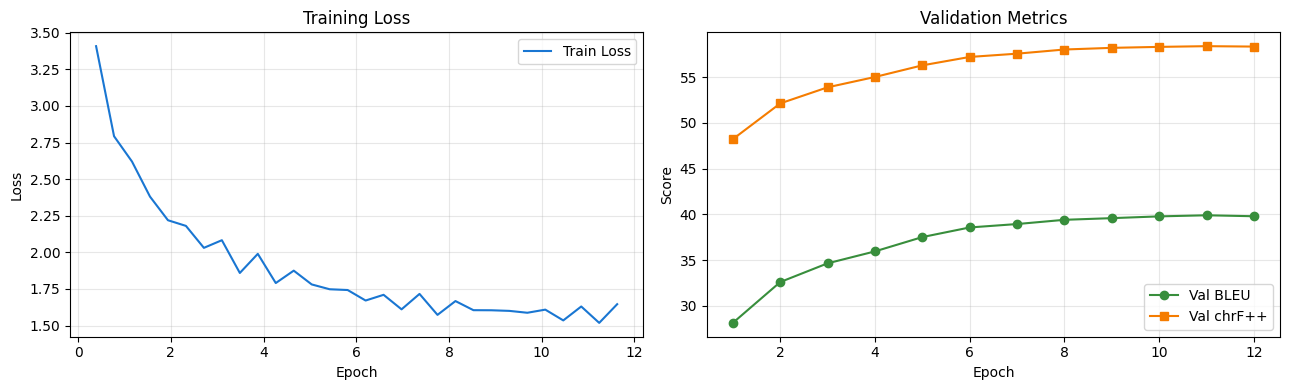

Val  BLEU=39.88 | chrF++=58.41
Test BLEU=39.33 | chrF++=59.10
Δ vs baseline test: BLEU=+27.67 | chrF++=+27.94


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RUN: marian_lr3e-5 | learning_rate=3e-05


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Train loss cuối: 1.4357


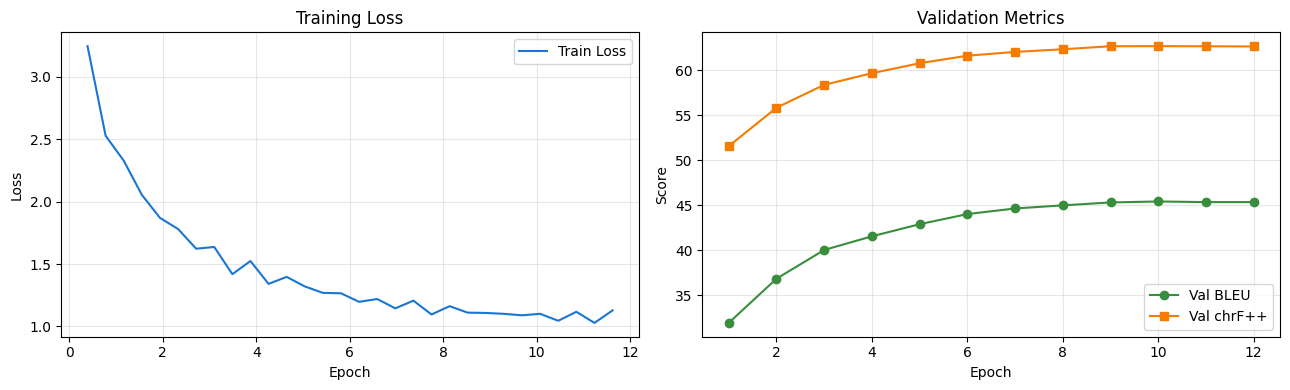

Val  BLEU=45.38 | chrF++=62.64
Test BLEU=45.82 | chrF++=64.03
Δ vs baseline test: BLEU=+34.16 | chrF++=+32.88


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RUN: marian_lr5e-5 | learning_rate=5e-05


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight', 'lm_head.weight'].


Train loss cuối: 1.2252


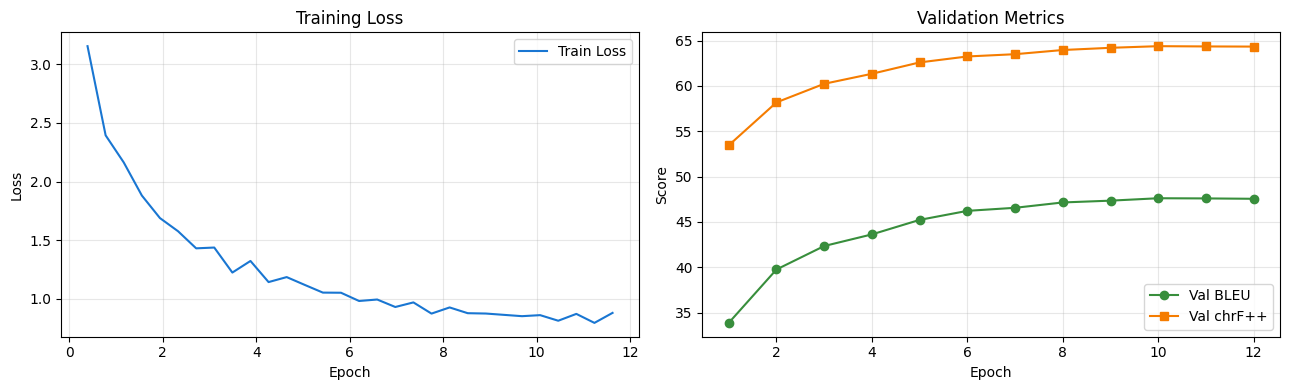

Val  BLEU=47.59 | chrF++=64.37
Test BLEU=48.41 | chrF++=65.84
Δ vs baseline test: BLEU=+36.76 | chrF++=+34.69


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,run_id,learning_rate,val_bleu,val_chrf,test_bleu,test_chrf,train_loss,run_dir
0,marian_lr5e-5,0.00005,47.5904,64.3737,48.4134,65.8429,1.225243,/content/drive/MyDrive/PhilosophyMT/runs/maria...
1,marian_lr3e-5,0.00003,45.3846,62.6376,45.8165,64.0285,1.435743,/content/drive/MyDrive/PhilosophyMT/runs/maria...
2,marian_lr1e-5,0.00001,39.8820,58.4052,39.3259,59.0951,1.880993,/content/drive/MyDrive/PhilosophyMT/runs/maria...


Sweep summary saved: /content/drive/MyDrive/PhilosophyMT/runs/marian_lr_sweep_summary.json


In [12]:
sweep_results = []
for learning_rate in LEARNING_RATES:
    result = run_marian_experiment(learning_rate)
    sweep_results.append(result)

sweep_df = pd.DataFrame(sweep_results)
sweep_df = sweep_df.sort_values('test_chrf', ascending=False).reset_index(drop=True)
display(sweep_df)

with open(RUNS_ROOT / 'marian_lr_sweep_summary.json', 'w', encoding='utf-8') as f:
    json.dump(sweep_results, f, indent=2, ensure_ascii=False)

print(f'Sweep summary saved: {RUNS_ROOT / "marian_lr_sweep_summary.json"}')


## 11. Demo model tốt nhất


In [13]:
best_run_id = sweep_df.iloc[0]['run_id']
best_model_dir = RUNS_ROOT / best_run_id / 'model'
print(f'Best run: {best_run_id}')

best_model = MarianMTModel.from_pretrained(best_model_dir).to(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
best_tokenizer = MarianTokenizer.from_pretrained(best_model_dir)
best_model.eval()


def translate(text: str, mdl=best_model, src_tokenizer=best_tokenizer, num_beams: int = 4) -> str:
    device = next(mdl.parameters()).device
    inputs = src_tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_SOURCE_LEN,
    ).to(device)
    with torch.no_grad():
        output = mdl.generate(
            **inputs,
            num_beams=num_beams,
            max_new_tokens=MAX_TARGET_LEN,
        )
    return src_tokenizer.decode(output[0], skip_special_tokens=True)


samples = test_df.sample(3, random_state=7)
for _, row in samples.iterrows():
    print('=' * 70)
    print(f"Topic   : {row['topic']}")
    print(f"\nEN      : {row['en'][:300]}")
    print(f"\nVI (ref): {row['vi'][:300]}")
    print(f"\nBest FT : {translate(row['en'])[:300]}")
    print()


Best run: marian_lr5e-5


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Topic   : Immanuel Kant

EN      : Kant’s first purely philosophical work was the New Elucidation of the First Principles of Metaphysical Cognition (1755). The first parts of this long essay present criticisms and revisions of the Wolffian understanding of the basic principles of metaphysics, especially the Principles of Identity ( w

VI (ref): Tác phẩm thuần triết học đầu tiên của Kant là Sự soi sáng mới về những nguyên lý đầu tiên của nhận thức siêu hình học (1755). Những phần đầu của tiểu luận dài này trình bày các phê phán và điều chỉnh đối với cách hiểu kiểu Wolff về các nguyên lý cơ bản của siêu hình học, đặc biệt là Nguyên lý Đồng n

Best FT : Tác phẩm đầu tiên thuần túy triết học của Kant là Sự dao động hóa mới của Những Nguyên lý Siêu hình học đệ nhất (1755). Những phần đầu của tiểu luận dài này trình bày những phê phán và sửa đổi về cách hiểu theo kiểu Wolffsian về các nguyên lý cơ bản của siêu hình học, đặc biệt là các nguyên lý của t

Topic   : Benedict de Spinoza: Epistemo

## 12. Tải lại model tốt nhất

```python
from transformers import MarianMTModel, MarianTokenizer

BEST_MODEL_DIR = '/content/drive/MyDrive/PhilosophyMT/runs/<best_run_id>/model'
tokenizer = MarianTokenizer.from_pretrained(BEST_MODEL_DIR)
model = MarianMTModel.from_pretrained(BEST_MODEL_DIR)
model.eval()
```
